In [59]:
"""
ECM Neural ODE — clean grey-box battery model
==============================================
Physics:
    V      =  U_eq - η
    η      =  R0(u,I)·I  +  V_rc
    dV_rc/dt  =  NN(V_rc, I, SoC, u)   ← what we learn

Design rules:
  • Model class only owns the neural network — NO rollout, NO loss.
  • rollout() lives outside the model; change it without retraining.
  • Two-stage training: (1) static R0 only, (2) add RC dynamics.
  • All training uses teacher forcing on V_rc (not on η directly).
"""

import sys
import torch
import torch.nn as nn
import pandas as pd
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# ─────────────────────────────────────────────────────────────
# 0.  Configuration
# ─────────────────────────────────────────────────────────────
DT = 1.0          # seconds per timestep
HIDDEN = 128


# ─────────────────────────────────────────────────────────────
# 1.  Known physics (not learned)
# ─────────────────────────────────────────────────────────────
def R0_func(u: torch.Tensor, I: torch.Tensor) -> torch.Tensor:
    """Ohmic resistance — fixed analytical expression."""
    return -0.0001887521 * u - 7.049519e-5 * I + 0.008446693


# ─────────────────────────────────────────────────────────────
# 2.  The Neural ODE  (only learns dV_rc/dt)
# ─────────────────────────────────────────────────────────────
class RCDynamicsNet(nn.Module):
    """
    Inputs  : V_rc (B,), I (B,), SoC (B,), u (B,)
    Output  : dV_rc/dt  (B,)

    No activation constraint on the output — the sign of dV_rc/dt
    is NOT fixed: it is positive at current-on transient,
    negative during relaxation.
    """
    def __init__(self, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        # Initialise to small outputs → V_rc starts near zero dynamics
        nn.init.uniform_(self.net[-1].weight, -1e-3, 1e-3)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, V_rc, I, SoC, u):
        """All tensors shape (B,) → returns dV_rc/dt shape (B,)."""
        x = torch.stack([V_rc, I, SoC, u], dim=-1)   # (B, 4)
        return self.net(x).squeeze(-1)                # (B,)


# ─────────────────────────────────────────────────────────────
# 3.  Helpers
# ─────────────────────────────────────────────────────────────
def masked_mse(pred: torch.Tensor, target: torch.Tensor,
               mask: torch.Tensor) -> torch.Tensor:
    """MSE over valid (non-padded) entries only."""
    return ((pred - target) ** 2)[mask].mean()


def decompose(x_b, y_b):
    """Extract named signals from batch tensors."""
    I      = x_b[:, :, 0]   # current
    u      = x_b[:, :, 1]   # displacement
    SoC    = x_b[:, :, 2]   # state of charge
    U_eq   = x_b[:, :, 3]   # equilibrium voltage
    V_true = y_b[:, :, 0]   # terminal voltage
    eta    = y_b[:, :, 2]   # overpotential (observed)
    # Decompose overpotential → RC voltage using known R0
    V_rc_true = eta - R0_func(u, I) * I
    return I, u, SoC, U_eq, V_true, eta, V_rc_true


# ─────────────────────────────────────────────────────────────
# 4.  Teacher-forcing loss  (TRAINING ONLY)
# ─────────────────────────────────────────────────────────────
def teacher_forcing_loss(model: RCDynamicsNet, x_b, y_b, mask_b,
                         w_deriv: float = 0.1):
    """
    At every step t, feed the TRUE V_rc[t] and predict V_rc[t+1].
    This gives well-conditioned gradients (no error accumulation).

    w_deriv: weight for the derivative loss (secondary signal).
    """
    I, u, SoC, U_eq, _, _, V_rc_true = decompose(x_b, y_b)

    # Predicted derivative at each t  (teacher forcing: use true state)
    dV_rc_pred = model(
        V_rc_true[:, :-1],   # (B, T-1)
        I[:, :-1],
        SoC[:, :-1],
        u[:, :-1],
    )

    # Euler step to predicted next state
    V_rc_next_pred = V_rc_true[:, :-1] + dV_rc_pred * DT   # (B, T-1)
    V_rc_next_true = V_rc_true[:, 1:]                       # (B, T-1)
    dV_rc_true     = (V_rc_next_true - V_rc_true[:, :-1]) / DT

    valid = mask_b[:, 1:]
    loss_state = masked_mse(V_rc_next_pred, V_rc_next_true, valid)
    loss_deriv = masked_mse(dV_rc_pred,     dV_rc_true,     valid)

    return loss_state + w_deriv * loss_deriv


# ─────────────────────────────────────────────────────────────
# 5.  Free rollout  (EVALUATION — outside the model class)
# ─────────────────────────────────────────────────────────────
@torch.no_grad()
def rollout(model: RCDynamicsNet, x_b, y_b, mask_b):
    """
    Autoregressive evaluation: each step feeds the *predicted* V_rc.
    Lives outside the model → modify this without ever retraining.

    Returns
    -------
    V_pred    (B, T)   predicted terminal voltage
    eta_pred  (B, T)   predicted overpotential
    V_rc_pred (B, T)   predicted RC voltage
    """
    model.eval()
    I, u, SoC, U_eq, _, eta_true, V_rc_true = decompose(x_b, y_b)
    B, T = I.shape

    # Initialise RC voltage from data at t=0  (ECM-consistent start)
    V_rc = V_rc_true[:, 0].clone()   # (B,)

    V_rc_preds = []
    for t in range(T):
        V_rc_preds.append(V_rc)

        dV_rc = model(V_rc, I[:, t], SoC[:, t], u[:, t])
        V_rc_new = V_rc + dV_rc * DT

        # On padded steps: hold state unchanged (no contamination)
        V_rc = torch.where(mask_b[:, t], V_rc_new, V_rc)

    V_rc_pred = torch.stack(V_rc_preds, dim=1)          # (B, T)
    eta_pred  = R0_func(u, I) * I + V_rc_pred           # (B, T)
    V_pred    = U_eq - eta_pred                          # (B, T)

    return V_pred, eta_pred, V_rc_pred


# ─────────────────────────────────────────────────────────────
# 6.  Training loop
# ─────────────────────────────────────────────────────────────
def train(model: RCDynamicsNet, loader_train, loader_val=None,
          epochs: int = 200, lr: float = 1e-3,
          w_deriv: float = 0.1):
    """Standard Adam + ReduceLROnPlateau training."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=15, factor=0.5)
    history = {"train": [], "val": []}

    for ep in range(1, epochs + 1):
        # ── train
        model.train()
        ep_loss = 0.0
        for x_b, y_b, mask_b in loader_train:
            loss = teacher_forcing_loss(model, x_b, y_b, mask_b, w_deriv)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= len(loader_train)
        history["train"].append(ep_loss)

        # ── validate (teacher forcing, no gradient)
        if loader_val is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_b, y_b, mask_b in loader_val:
                    val_loss += teacher_forcing_loss(
                        model, x_b, y_b, mask_b, w_deriv).item()
            val_loss /= len(loader_val)
            history["val"].append(val_loss)
            scheduler.step(val_loss)
        else:
            scheduler.step(ep_loss)

        if ep % 20 == 0 or ep == 1:
            val_str = f"  val {val_loss:.3e}" if loader_val else ""
            print(f"Epoch {ep:4d} | train {ep_loss:.3e}{val_str}")

    return history


# ─────────────────────────────────────────────────────────────
# 7.  Two-stage training helper
# ─────────────────────────────────────────────────────────────
def two_stage_train(loader_train, loader_val=None):
    """
    Stage 1: Learn only the static η ≈ R0·I part → no ODE needed,
             just verify the R0 function fits.  (diagnostic, optional)

    Stage 2: Train RCDynamicsNet on teacher-forcing loss.
             Start with high w_deriv to stabilise early; decay it.
    """
    model = RCDynamicsNet(hidden=HIDDEN)

    print("=== Stage 1: high derivative weight (stabilise) ===")
    history1 = train(model, loader_train, loader_val,
                     epochs=100, lr=1e-3, w_deriv=1.0)

    print("\n=== Stage 2: low derivative weight (refine state) ===")
    history2 = train(model, loader_train, loader_val,
                     epochs=200, lr=3e-4, w_deriv=0.05)

    all_loss = history1["train"] + history2["train"]
    return model, all_loss


# ─────────────────────────────────────────────────────────────
# 8.  Plotting utility
# ─────────────────────────────────────────────────────────────
def plot_trajectory(idx, model, X_test, Y_test, mask_test):
    """Plot one test trajectory: V and V_rc, rollout vs truth."""
    V_pred, eta_pred, V_rc_pred = rollout(model, X_test, Y_test, mask_test)

    I, u, _, _, _, eta_true, V_rc_true = decompose(X_test, Y_test)
    t_max = mask_test[idx].sum().item() - 2800
    t_ax  = range(t_max)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Terminal voltage
    axes[0].plot(t_ax, Y_test[idx, :t_max, 0], '--', color=colors[1], label='True V')
    axes[0].plot(t_ax, V_pred[idx, :t_max],  color=colors[0],   label='Pred V')
    axes[0].set(title='Terminal voltage', xlabel='Timestep', ylabel='V [V]')
    axes[0].legend()

    # Overpotential
    axes[1].plot(t_ax, eta_true[idx, :t_max], '--', color=colors[1], label=r'True $\eta$')
    axes[1].plot(t_ax, eta_pred[idx, :t_max], color=colors[0],   label='Pred $\eta$')
    axes[1].set(title='Overpotential', xlabel='Timestep', ylabel='$\eta$ [V]')
    axes[1].legend()

    # RC voltage (the state learned by the ODE)
    axes[2].plot(t_ax, V_rc_true[idx, :t_max], '--', color=colors[1], label='True V_rc')
    axes[2].plot(t_ax, V_rc_pred[idx, :t_max], color=colors[0],   label='Pred V_rc')
    axes[2].set(title='RC voltage (ODE state)', xlabel='Timestep', ylabel='V_rc [V]')
    axes[2].legend()

    plt.tight_layout()
    # plt.savefig('/mnt/user-data/outputs/trajectory_plot.png', dpi=150)
    plt.show()


# ─────────────────────────────────────────────────────────────
# 9.  Quick sanity check  (run before full training)
# ─────────────────────────────────────────────────────────────
def sanity_check(x_b, y_b, mask_b):
    """
    Print key statistics before training.
    If R0*I >> V_rc, normalise V_rc before feeding into the net.
    """
    I, u, SoC, U_eq, V_true, eta, V_rc_true = decompose(x_b, y_b)
    valid = mask_b

    print("─── Sanity check ───────────────────────────────────")
    print(f"η         : mean={eta[valid].mean():.4f}  std={eta[valid].std():.4f}")
    print(f"R0·I      : mean={(R0_func(u,I)*I)[valid].mean():.4f}"
          f"  std={(R0_func(u,I)*I)[valid].std():.4f}")
    print(f"V_rc      : mean={V_rc_true[valid].mean():.4f}"
          f"  std={V_rc_true[valid].std():.4f}")
    dv = (V_rc_true[:, 1:] - V_rc_true[:, :-1]) / DT
    print(f"dV_rc/dt  : min={dv[valid[:,1:]].min():.4f}"
          f"  max={dv[valid[:,1:]].max():.4f}")
    frac = (V_rc_true[valid].abs() / eta[valid].abs()).mean()
    print(f"|V_rc|/|η|: {frac:.1%}   ← if <5%, R0 dominates; consider skipping RC")
    print("────────────────────────────────────────────────────")


# ─────────────────────────────────────────────────────────────
# 10.  Usage template (paste into your notebook)
# ─────────────────────────────────────────────────────────────
USAGE = """
# ── In your notebook ──────────────────────────────────────────

from ecm_node import (RCDynamicsNet, two_stage_train,
                      rollout, plot_trajectory, sanity_check)

# 1. Sanity check BEFORE any training
x_b, y_b, mask_b = next(iter(loader_train))
sanity_check(x_b, y_b, mask_b)

# 2. Train
model, loss_curve = two_stage_train(loader_train, loader_val=loader_test)

# 3. Evaluate — change rollout() any time without retraining
V_pred, eta_pred, V_rc_pred = rollout(model, X_test, Y_test, mask_test)

# 4. Plot
plot_trajectory(idx=0, model=model,
                X_test=X_test, Y_test=Y_test, mask_test=mask_test)

# 5. Save / reload
import torch
torch.save(model.state_dict(), 'ecm_node.pt')
model2 = RCDynamicsNet(); model2.load_state_dict(torch.load('ecm_node.pt'))
V_pred2, _, _ = rollout(model2, X_test, Y_test, mask_test)   # same result
"""

if __name__ == "__main__":
    print(USAGE)


# ── In your notebook ──────────────────────────────────────────

from ecm_node import (RCDynamicsNet, two_stage_train,
                      rollout, plot_trajectory, sanity_check)

# 1. Sanity check BEFORE any training
x_b, y_b, mask_b = next(iter(loader_train))
sanity_check(x_b, y_b, mask_b)

# 2. Train
model, loss_curve = two_stage_train(loader_train, loader_val=loader_test)

# 3. Evaluate — change rollout() any time without retraining
V_pred, eta_pred, V_rc_pred = rollout(model, X_test, Y_test, mask_test)

# 4. Plot
plot_trajectory(idx=0, model=model,
                X_test=X_test, Y_test=Y_test, mask_test=mask_test)

# 5. Save / reload
import torch
torch.save(model.state_dict(), 'ecm_node.pt')
model2 = RCDynamicsNet(); model2.load_state_dict(torch.load('ecm_node.pt'))
V_pred2, _, _ = rollout(model2, X_test, Y_test, mask_test)   # same result



<>:262: SyntaxWarning: invalid escape sequence '\e'
<>:263: SyntaxWarning: invalid escape sequence '\e'
<>:262: SyntaxWarning: invalid escape sequence '\e'
<>:263: SyntaxWarning: invalid escape sequence '\e'
/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_17509/3104145733.py:262: SyntaxWarning: invalid escape sequence '\e'
  axes[1].plot(t_ax, eta_pred[idx, :t_max], color=colors[0],   label='Pred $\eta$')
/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_17509/3104145733.py:263: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set(title='Overpotential', xlabel='Timestep', ylabel='$\eta$ [V]')


In [37]:
def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

path = f'2_merged_data'

data = read_data(path)
data['eta'] = - data['eta']  # Negate eta to match model convention
# display(data)

In [38]:
# Batch data
feature_cols = ['I', 'u', 'soc', 'Ue']
target_cols  = ['V', 'F', 'eta']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data['trajectory'].value_counts().sort_index().values
B     = len(traj_lengths)  # number of trajectories
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

In [39]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, batch_size=X_train.shape[0]//4, shuffle=True)
loader_test   = DataLoader(dataset_test, batch_size=X_test.shape[0]//4, shuffle=False)

Train: torch.Size([198, 7049, 4])  |  Test: torch.Size([50, 7049, 4])


In [40]:
x_b, y_b, mask_b = next(iter(loader_train))
sanity_check(x_b, y_b, mask_b)

─── Sanity check ───────────────────────────────────
η         : mean=0.1889  std=0.1243
R0·I      : mean=0.0815  std=0.0405
V_rc      : mean=0.1074  std=0.0973
dV_rc/dt  : min=-0.0004  max=0.0707
|V_rc|/|η|: 52.8%   ← if <5%, R0 dominates; consider skipping RC
────────────────────────────────────────────────────


In [41]:
model, loss_curve = two_stage_train(loader_train, loader_val=loader_test)

=== Stage 1: high derivative weight (stabilise) ===
Epoch    1 | train 1.051e-03  val 7.625e-04
Epoch   20 | train 1.298e-05  val 1.384e-05
Epoch   40 | train 1.073e-05  val 1.146e-05
Epoch   60 | train 1.091e-05  val 8.564e-06
Epoch   80 | train 6.771e-06  val 7.201e-06
Epoch  100 | train 6.628e-06  val 6.919e-06

=== Stage 2: low derivative weight (refine state) ===
Epoch    1 | train 3.084e-05  val 2.650e-05
Epoch   20 | train 5.147e-06  val 3.612e-06
Epoch   40 | train 3.251e-06  val 3.574e-06
Epoch   60 | train 3.330e-06  val 3.486e-06
Epoch   80 | train 3.619e-06  val 3.406e-06
Epoch  100 | train 3.352e-06  val 3.504e-06
Epoch  120 | train 3.169e-06  val 3.329e-06
Epoch  140 | train 2.961e-06  val 3.306e-06
Epoch  160 | train 2.858e-06  val 3.316e-06
Epoch  180 | train 3.344e-06  val 3.264e-06
Epoch  200 | train 3.537e-06  val 3.250e-06


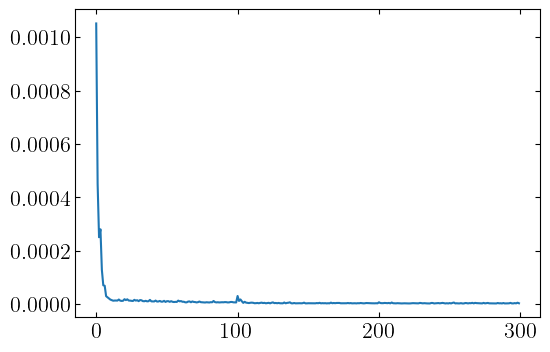

In [42]:
plt.figure(figsize=(6,4))
plt.plot(loss_curve);

In [51]:
V_pred, eta_pred, V_rc_pred = rollout(model, X_test, Y_test, mask_test)

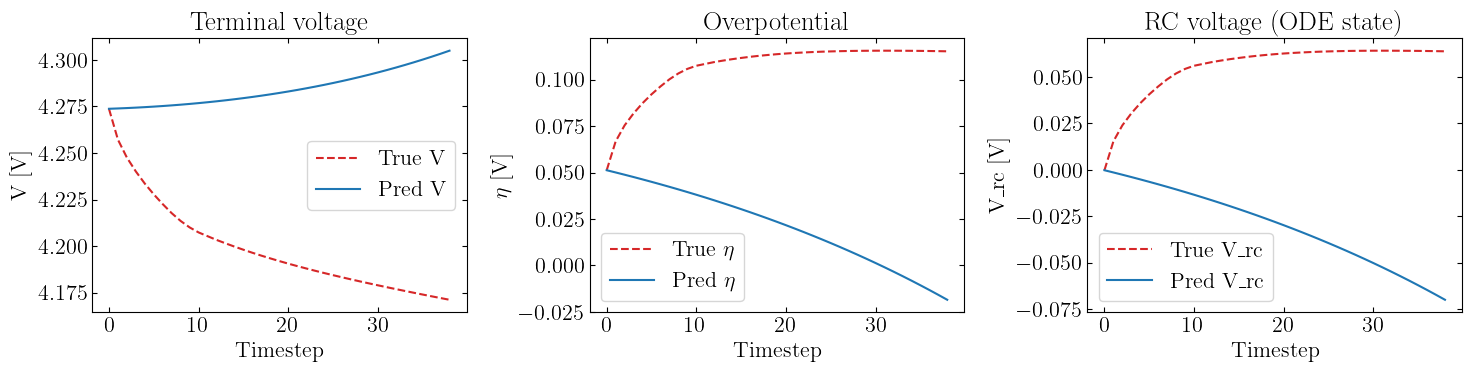

In [60]:
plot_trajectory(idx=0, model=model, X_test=X_test, Y_test=Y_test, mask_test=mask_test)